# **Mount Google Drive**

In [2]:
from google.colab import drive
drive.mount('/content/drive')
BASE_PATH = "/content/drive/MyDrive/reuters_text_classification"
MODELS_PATH = f"{BASE_PATH}/models"
NOTEBOOKS_PATH = f"{BASE_PATH}/notebooks"

Mounted at /content/drive


# **Data download and preprocessing** #

***Download and split the data***

In [3]:
from tensorflow.keras.datasets import reuters
from sklearn.model_selection import train_test_split
import numpy as np

# Load dataset with an 80/20 split between training and testing
(X_train, y_train), (X_test, y_test) = reuters.load_data(test_split=0.2)

# See the first few rows of X_train and y_train to verify the download worked
print(X_train[:3])
print('\n',y_train[:3])

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
[list([1, 27595, 28842, 8, 43, 10, 447, 5, 25, 207, 270, 5, 3095, 111, 16, 369, 186, 90, 67, 7, 89, 5, 19, 102, 6, 19, 124, 15, 90, 67, 84, 22, 482, 26, 7, 48, 4, 49, 8, 864, 39, 209, 154, 6, 151, 6, 83, 11, 15, 22, 155, 11, 15, 7, 48, 9, 4579, 1005, 504, 6, 258, 6, 272, 11, 15, 22, 134, 44, 11, 15, 16, 8, 197, 1245, 90, 67, 52, 29, 209, 30, 32, 132, 6, 109, 15, 17, 12])
 list([1, 3267, 699, 3434, 2295, 56, 16784, 7511, 9, 56, 3906, 1073, 81, 5, 1198, 57, 366, 737, 132, 20, 4093, 7, 19261, 49, 2295, 13415, 1037, 3267, 699, 3434, 8, 7, 10, 241, 16, 855, 129, 231, 783, 5, 4, 587, 2295, 13415, 30625, 775, 7, 48, 34, 191, 44, 35, 1795, 505, 17, 12])
 list([1, 53, 12, 284, 15, 14, 272, 26, 53, 959, 32, 818, 15, 14, 272, 26, 39, 684, 70, 11, 14, 12, 3886, 18, 180, 183, 187, 70, 11, 14, 102, 32, 11, 29, 53, 44, 704, 15, 14, 19, 758, 15, 53, 959, 47, 1013, 15, 14, 19, 132, 15, 39, 965, 32, 11, 14, 147, 72, 11, 180, 183, 187, 44, 11, 14, 102, 19,

***Translate integers to words***

In [4]:
# Get the word-to-index mapping
word_index = reuters.get_word_index()

# Flip it so it becomes an index-to-word mapping
text_index = {value: key for key, value in word_index.items()}

# Test if it works
print(text_index[27595])


550378/550378 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
wattie


***Vectorize the training dataset***

In [5]:
# Array will hold the decoded text for X_train
X_train_text = []

# Decode training data from integer into text
for index_word_pair in X_train:
    X_train_word_array = []
    for this_word in index_word_pair:
        current_word = text_index.get(this_word - 3, '?')
        X_train_word_array.append(current_word)
    current_sentence = ' '.join(X_train_word_array)
    X_train_text.append(current_sentence)


***Vectorize the testing dataset***

In [6]:
# Array will hold the decoded text for X_test
X_test_text = []

# Decode test data
for index_word_pair in X_test:
    X_test_word_array = []
    for this_word in index_word_pair:
        current_word = text_index.get(this_word - 3, '?')
        X_test_word_array.append(current_word)
    X_test_sentence = ' '.join(X_test_word_array)
    X_test_text.append(X_test_sentence)


***Convert text to TF-IDF vectors for SVM model***

In [7]:
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.feature_extraction.text import TfidfVectorizer as tfidf

# Convert text
vector = tfidf(max_features=None,  # Let min_df/max_df decide
               min_df=5,
               max_df=0.9)
X_train_vector = vector.fit_transform(X_train_text)
X_test_vector = vector.transform(X_test_text)
print(len(vector.vocabulary_))

9101


# **Phase 1: SVM model**

In [8]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

# Choose C=1 as an initial C
svm_model = LinearSVC(C=1,
                      class_weight = 'balanced')
svm_model.fit(X_train_vector, y_train)

# Perform initial predictions and evaluate results
y_pred_svm = svm_model.predict(X_test_vector)
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm)}")
print(f"Classification report:\n{classification_report(y_test, y_pred_svm)}")


Accuracy: 0.8308103294746215
Classification report:
              precision    recall  f1-score   support

           0       0.80      0.67      0.73        12
           1       0.76      0.77      0.77       105
           2       0.77      0.85      0.81        20
           3       0.95      0.92      0.93       813
           4       0.87      0.88      0.87       474
           5       0.33      0.20      0.25         5
           6       0.81      0.93      0.87        14
           7       0.75      1.00      0.86         3
           8       0.66      0.71      0.68        38
           9       0.80      0.96      0.87        25
          10       0.82      0.93      0.88        30
          11       0.70      0.73      0.72        83
          12       0.50      0.54      0.52        13
          13       0.67      0.76      0.71        37
          14       0.29      1.00      0.44         2
          15       0.67      0.44      0.53         9
          16       0.77      

***Attempt to improve the model by tuning the hyperparamter C***

In [9]:
from sklearn.model_selection import cross_val_score

# Test different C values
c_values = [0.01, 0.1, 1.0, 10.0, 100.0]
best_C = None
best_score = 0

# Iterate over the 5 c_values
for test_c in c_values:

    # create a model based on test_c
    svm_model = LinearSVC(C=test_c)  #Linear is best for clean text

    # Score the model on 5-fold cross-validation. Use n_jobs=-1 for speed purposes
    result = cross_val_score(svm_model, X_train_vector, y_train, cv=5, scoring='accuracy', n_jobs=-1)

    # Average the resultant scores
    ave_result = np.mean(result)

    # Print the averaged accuracy and standard deviation
    print(f"C={test_c}: Mean CV Accuracy = {ave_result:.4f} (±{np.std(result):.4f})")

    # Hold the C value based on the best average mean score
    if ave_result > best_score:
        best_score = ave_result
        best_C = test_c

# Print best C
print("\nBest C value:", best_C)
print("Best mean CV accuracy:", best_score)

C=0.01: Mean CV Accuracy = 0.6899 (±0.0064)
C=0.1: Mean CV Accuracy = 0.8308 (±0.0062)
C=1.0: Mean CV Accuracy = 0.8408 (±0.0063)
C=10.0: Mean CV Accuracy = 0.8199 (±0.0060)
C=100.0: Mean CV Accuracy = 0.8100 (±0.0048)

Best C value: 1.0
Best mean CV accuracy: 0.8407933043565556


***A C-value of 1 had the best accuracy (in my run). Further tuning by setting C-values between 1 and 10, inclusive***

In [10]:
c_values = range(1, 11)
best_C = None
best_score = 0

# Iterate over the 10 c_values
for test_c in c_values:
    # create a model based on test_c
    svm_model = LinearSVC(C=test_c)

    # Score the model on 5-fold cross-validation. Use n_jobs=-1 for speed purposes
    result = cross_val_score(svm_model, X_train_vector, y_train, cv=5, scoring='accuracy', n_jobs=-1)

    # Average the resultant scores
    ave_result = np.mean(result)

    # Print the averaged accuracy and standard deviation
    print(f"C={test_c}: Mean CV Accuracy = {ave_result:.4f} (±{np.std(result):.4f})")

    # Hold the C value based on the best average mean score
    if ave_result > best_score:
        best_score = ave_result
        best_C = test_c

# Print best C
print("\nBest C value:", best_C)
print("Best mean CV accuracy:", best_score)

C=1: Mean CV Accuracy = 0.8408 (±0.0063)
C=2: Mean CV Accuracy = 0.8314 (±0.0069)
C=3: Mean CV Accuracy = 0.8271 (±0.0060)
C=4: Mean CV Accuracy = 0.8257 (±0.0057)
C=5: Mean CV Accuracy = 0.8235 (±0.0054)
C=6: Mean CV Accuracy = 0.8222 (±0.0050)
C=7: Mean CV Accuracy = 0.8213 (±0.0056)
C=8: Mean CV Accuracy = 0.8206 (±0.0056)
C=9: Mean CV Accuracy = 0.8203 (±0.0059)
C=10: Mean CV Accuracy = 0.8199 (±0.0060)

Best C value: 1
Best mean CV accuracy: 0.8407933043565556


***Fit the model with the best C-value and display the accuracy***

In [11]:
# Choose C=1 as it was determined to be the best value
svm_model = LinearSVC(C=1,
                      class_weight = 'balanced')
svm_model = svm_model.fit(X_train_vector, y_train)

# Perform predictions and evaluate results
y_pred_svm = svm_model.predict(X_test_vector)
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.3f}\n")
print(f"Classification report:\n{classification_report(y_test, y_pred_svm)}")

Accuracy: 0.831

Classification report:
              precision    recall  f1-score   support

           0       0.80      0.67      0.73        12
           1       0.76      0.77      0.77       105
           2       0.77      0.85      0.81        20
           3       0.95      0.92      0.93       813
           4       0.87      0.88      0.87       474
           5       0.33      0.20      0.25         5
           6       0.81      0.93      0.87        14
           7       0.75      1.00      0.86         3
           8       0.66      0.71      0.68        38
           9       0.80      0.96      0.87        25
          10       0.82      0.93      0.88        30
          11       0.70      0.73      0.72        83
          12       0.50      0.54      0.52        13
          13       0.67      0.76      0.71        37
          14       0.29      1.00      0.44         2
          15       0.67      0.44      0.53         9
          16       0.77      0.82      0.

# **Phase 2: Build the CNN model using raw integer sequences**

***This piece will help increase visibility of minor classes without pulling down weighting (much) of major classes***

In [12]:
def scaled_class_weights(base_dict, scale):
    return {cls: 1.0 + (w - 1.0) * scale for cls, w in base_dict.items()}

***Load the data and build the training and test sets***

In [13]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
#load
(x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=15000)

#pad sequence
maxlen = 300
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

#number of classes
num_classes = int(np.max(y_train) + 1)

***Change the label values to categories by one-hot encoding***

In [14]:
from tensorflow.keras.utils import to_categorical
#oneHot Encode Labels
y_train_cnn = to_categorical(y_train, num_classes)
y_test_cnn = to_categorical(y_test, num_classes)

***Create class weighting dictionary***

In [15]:
from sklearn.utils.class_weight import compute_class_weight

# y_train is one-hot encoded so convert back to class IDs
y_train_labels = np.argmax(y_train_cnn, axis=1)

# Load the class labels
classes = np.unique(y_train_labels)

# Compute the weights
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_labels
)

# Fill the dictionary
class_weight_dict = dict(zip(classes, weights))

# Retrieve and save the weightings.
class_weightings = scaled_class_weights(class_weight_dict, 0.1)

***Import libraries and build the model***

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

#build CNN Model
cnn_model = Sequential([
    Embedding(input_dim=15000, output_dim=128),
    Conv1D(filters=64, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

***Compile the model***

In [17]:
#complile the CNN model
cnn_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

***Train and evaluate the model***

In [18]:
history = cnn_model.fit(
    x_train, y_train_cnn,
    epochs=100, # no early stopping set yet
    batch_size=128,
    validation_split=0.2,
    class_weight=class_weightings
)

# Evaluate the results
test_loss, test_acc = cnn_model.evaluate(x_test, y_test_cnn)
print(f"Test Accuracy: {test_acc:.4f}")

# Save the predictions for later comparisons
y_pred_cnn = cnn_model.predict(x_test)
y_pred_cnn_classes = y_pred_cnn.argmax(axis=1)
y_true_cnn_classes = np.argmax(y_test_cnn, axis=1)

Epoch 1/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - accuracy: 0.3539 - loss: 2.8649 - val_accuracy: 0.4969 - val_loss: 1.9940
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5141 - loss: 2.1587 - val_accuracy: 0.5715 - val_loss: 1.7130
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5916 - loss: 1.9086 - val_accuracy: 0.6600 - val_loss: 1.5104
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6431 - loss: 1.7261 - val_accuracy: 0.6906 - val_loss: 1.3628
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6836 - loss: 1.5690 - val_accuracy: 0.7017 - val_loss: 1.2623
Epoch 6/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7070 - loss: 1.4205 - val_accuracy: 0.7190 - val_loss: 1.1961
Epoch 7/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7325 - loss: 1.2837 - val_accuracy: 0.7362 - val_loss: 1.1361
Epoch 8/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7623 - loss: 1.1475 - val_accuracy: 0.

***Plot the results - train accuracy vs test accuracy and train loss vs. test loss***




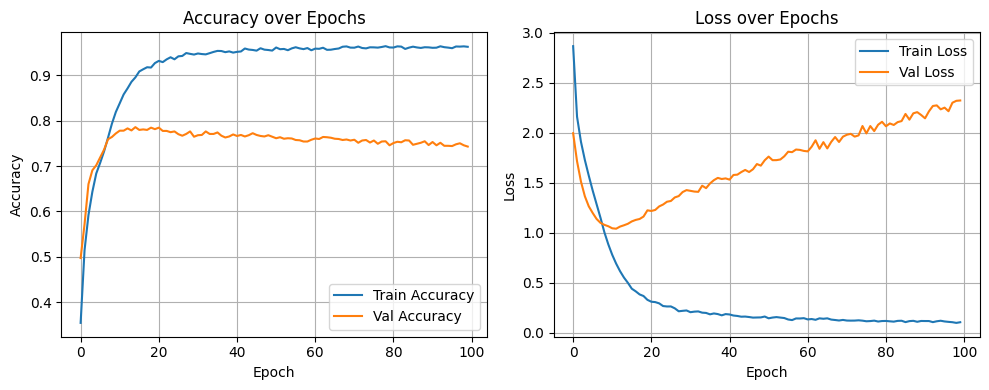

In [19]:
import matplotlib.pyplot as plt

#accuracy plot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

#loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

***Attempt embedding and multiple convolution layers***

In [20]:
#build tuned CNN model
cnn_model2 = Sequential([
    Embedding(input_dim=15000, output_dim=128),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

***Compile the model, use Early Stopping to reduce fitting time if not gaining any additional accuracy***

In [21]:
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

#compile with lower learning rate
cnn_model2.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0001),
    metrics=['accuracy']
)

#early stopping callback
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

#train the model, increase epochs to 100 as Early Stopping is defined
history2 = cnn_model2.fit(
    x_train, y_train_cnn,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight=class_weightings
)

#Evaluate the model
test_loss, test_acc = cnn_model2.evaluate(x_test, y_test_cnn)
print(f"Test Accuracy: {test_acc:.4f}")

y_pred_cnn2 = cnn_model2.predict(x_test)
y_pred_cnn2 = y_pred_cnn2.argmax(axis=1)

Epoch 1/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 8s 72ms/step - accuracy: 0.2728 - loss: 3.5992 - val_accuracy: 0.3450 - val_loss: 2.7545
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3491 - loss: 2.7838 - val_accuracy: 0.3450 - val_loss: 2.4536
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3691 - loss: 2.6691 - val_accuracy: 0.3556 - val_loss: 2.3526
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4445 - loss: 2.4839 - val_accuracy: 0.4914 - val_loss: 2.0932
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4971 - loss: 2.3175 - val_accuracy: 0.4964 - val_loss: 2.0198
Epoch 6/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5070 - loss: 2.2555 - val_accuracy: 0.5097 - val_loss: 1.9676
Epoch 7/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5140 - loss: 2.2018 - val_accuracy: 0.5142 - val_loss: 1.9084
Epoch 8/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5244 - loss: 2.1430 - val_accuracy: 0.

***Plot the results after using extra convoluting layers and early stopping***

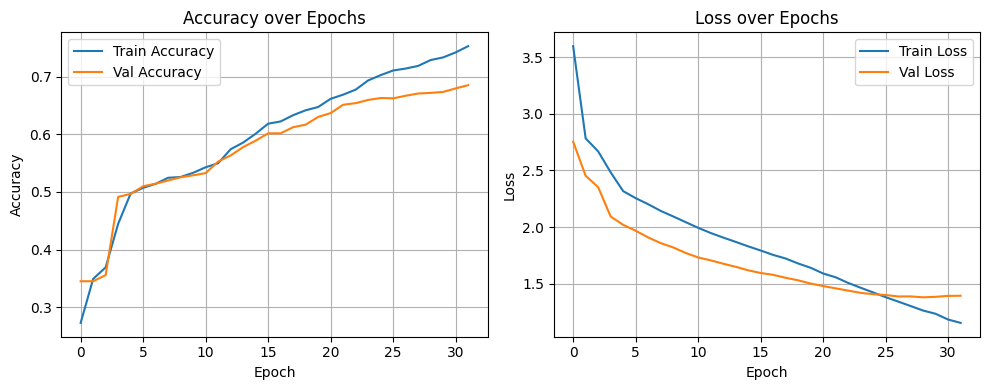

In [22]:
#plot training curves
plt.figure(figsize=(10, 4))

#accuracy
plt.subplot(1, 2, 1)
plt.plot(history2.history['accuracy'], label='Train Accuracy')
plt.plot(history2.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

#loss
plt.subplot(1, 2, 2)
plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# **Phase 3: Now create a CNN architecture with multiple filter sizes and richer feature extraction** #

In [23]:
# Number of words should match input dimensions
num_words = 15000

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Concatenate

input_layer = Input(shape=(maxlen,))
embedding = Embedding(input_dim=15000, output_dim=128)(input_layer)

branch_ksize3 = Conv1D(filters=128, kernel_size=3, activation='relu')(embedding)
branch_ksize3 = GlobalMaxPooling1D()(branch_ksize3)

branch_ksize4 = Conv1D(filters=128, kernel_size=4, activation='relu')(embedding)
branch_ksize4 = GlobalMaxPooling1D()(branch_ksize4)

branch_ksize5 = Conv1D(filters=128, kernel_size=5, activation='relu')(embedding)
branch_ksize5 = GlobalMaxPooling1D()(branch_ksize5)

merged_branches = Concatenate()([branch_ksize3, branch_ksize4, branch_ksize5])
merged_branches = Dropout(0.27)(merged_branches)
merged_branches = Dense(128, activation='relu')(merged_branches)
output = Dense(num_classes, activation='softmax')(merged_branches)

cnn_model3 = Model(inputs=input_layer, outputs=output)

# Compile
cnn_model3.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0004),
    metrics=['accuracy']
)

# Early stopping callback
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the model
history3 = cnn_model3.fit(
    x_train, y_train_cnn,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
    class_weight=class_weightings,
    callbacks=[early_stop]
)

test_loss, test_acc = cnn_model3.evaluate(x_test, y_test_cnn)
print(f"Test Accuracy: {test_acc:.4f}")

y_pred_cnn3 = cnn_model3.predict(x_test)
y_pred_cnn3 = y_pred_cnn3.argmax(axis=1)

Epoch 1/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - accuracy: 0.3790 - loss: 2.8617 - val_accuracy: 0.4914 - val_loss: 2.0315
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.5024 - loss: 2.1952 - val_accuracy: 0.5070 - val_loss: 1.8651
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.5645 - loss: 1.9796 - val_accuracy: 0.6416 - val_loss: 1.5966
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.6703 - loss: 1.7118 - val_accuracy: 0.6861 - val_loss: 1.3776
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.7024 - loss: 1.5234 - val_accuracy: 0.7129 - val_loss: 1.2668
Epoch 6/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.7372 - loss: 1.3638 - val_accuracy: 0.7295 - val_loss: 1.1667
Epoch 7/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.7596 - loss: 1.2294 - val_accuracy: 0.7462 - val_loss: 1.0983
Epoch 8/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.7834 - loss: 1.1133 - val_accuracy: 0.

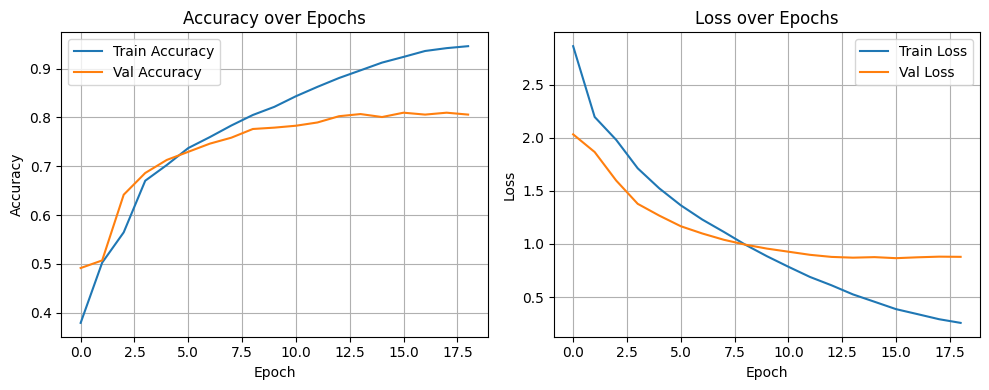

In [24]:
# plot training curves
plt.figure(figsize=(10, 4))

#accuracy
plt.subplot(1, 2, 1)
plt.plot(history3.history['accuracy'], label='Train Accuracy')
plt.plot(history3.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

#loss
plt.subplot(1, 2, 2)
plt.plot(history3.history['loss'], label='Train Loss')
plt.plot(history3.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# **Phase 4: Using tuned CNN with GLoVe, allowing the model to focus on classification instead of also needing to learn word interpretations from scratch** #

In [25]:
#num_words and maxlen already defined during SVM training

tokenizer = Tokenizer(num_words=num_words, oov_token="<UNK>") #<UNK> is a 'catch-all'
tokenizer.fit_on_texts(X_train_text) # build an internal vocabulary

# Make sequences for train and test sets
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

# pad them so each entry is the same length
X_train_pad = pad_sequences(X_train_seq, maxlen=maxlen)
X_test_pad = pad_sequences(X_test_seq, maxlen=maxlen)

***Gensim allows loading of the GLoVe vector file through an API instead of needing to download it***

In [26]:
# Needed if Gensim module not installed
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 57.1 MB/s eta 0:00:00


In [27]:
import gensim.downloader as api
word_vectors = api.load("glove-wiki-gigaword-100")

[==================================================] 100.0% 128.1/128.1MB downloaded


***Build the GloVe embedding matrix***

In [28]:
embedding_dim = 100
embedding_matrix = {}

vocab_size = min(num_words, len(tokenizer.word_index) + 1)
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():
    if i >= vocab_size:
        continue
    if word in word_vectors:
      embedding_vector = word_vectors[word]
    else:
      embedding_vector = None
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

***Build the CNN model using the GLoVe file in the Embedding layer***

In [29]:
input_layer = Input(shape=(maxlen,)) #define the input

# Apply the embedding layer
embedding = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    trainable=False
)

# Set up embedding layer as a Tensor, as needed for the CNN branches
embedding_GLoVe = embedding(input_layer)

branch_ksize3 = Conv1D(filters=128, kernel_size=3, activation='relu')(embedding_GLoVe)
branch_ksize3 = GlobalMaxPooling1D()(branch_ksize3)

branch_ksize4 = Conv1D(filters=128, kernel_size=4, activation='relu')(embedding_GLoVe)
branch_ksize4 = GlobalMaxPooling1D()(branch_ksize4)

branch_ksize5 = Conv1D(filters=128, kernel_size=5, activation='relu')(embedding_GLoVe)
branch_ksize5 = GlobalMaxPooling1D()(branch_ksize5)

merged_branches = Concatenate()([branch_ksize3, branch_ksize4, branch_ksize5])
merged_branches = Dropout(0.27)(merged_branches)
merged_branches = Dense(128, activation='relu')(merged_branches)
output = Dense(num_classes, activation='softmax')(merged_branches)

cnn_model4 = Model(inputs=input_layer, outputs=output)

# Compile
cnn_model4.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0004),
    metrics=['accuracy']
)

# Early stopping callback
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the model
history4 = cnn_model4.fit(
    x_train, y_train_cnn,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
    class_weight=class_weightings,
    callbacks=[early_stop]
)

test_loss, test_acc = cnn_model4.evaluate(x_test, y_test_cnn)
print(f"Test Accuracy: {test_acc:.4f}")

y_pred_cnn4 = cnn_model4.predict(x_test)
y_pred_cnn4 = y_pred_cnn4.argmax(axis=1)

Epoch 1/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - accuracy: 0.3706 - loss: 2.7913 - val_accuracy: 0.4786 - val_loss: 2.0920
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4732 - loss: 2.3361 - val_accuracy: 0.5125 - val_loss: 1.9495
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5125 - loss: 2.1444 - val_accuracy: 0.5582 - val_loss: 1.7870
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5496 - loss: 1.9984 - val_accuracy: 0.5771 - val_loss: 1.7011
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5936 - loss: 1.8690 - val_accuracy: 0.6210 - val_loss: 1.6127
Epoch 6/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6214 - loss: 1.7412 - val_accuracy: 0.6238 - val_loss: 1.5421
Epoch 7/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6465 - loss: 1.6327 - val_accuracy: 0.6555 - val_loss: 1.4841
Epoch 8/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6608 - loss: 1.5298 - val_accuracy: 0.

***Plot the results***

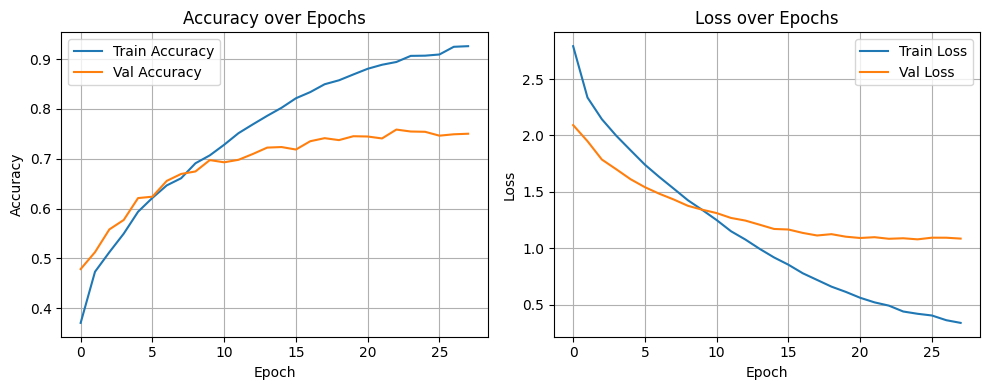

In [30]:
# plot training curves
plt.figure(figsize=(10, 4))

#accuracy
plt.subplot(1, 2, 1)
plt.plot(history4.history['accuracy'], label='Train Accuracy')
plt.plot(history4.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

#loss
plt.subplot(1, 2, 2)
plt.plot(history4.history['loss'], label='Train Loss')
plt.plot(history4.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# **Compare the results of the tuned SVM model and all CNN models** #

In [31]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
# Combine the results into a list
list_of_model_results = {
    "SVM": (y_test, y_pred_svm),
    "CNN_1": (y_test_cnn, y_pred_cnn),
    "CNN_2": (y_test_cnn, y_pred_cnn2),
    "CNN_3": (y_test_cnn, y_pred_cnn3),
    "CNN_4": (y_test_cnn, y_pred_cnn4)
}

# Tabulate the results
results_array = []

for name, (y_true, y_pred) in list_of_model_results.items():

    # Convert one-hot encoded true labels back to class labels if needed
    if len(y_true.shape) > 1:
        y_true_classes = np.argmax(y_true, axis=1)
    else:
        y_true_classes = y_true

    # Convert predicted probabilities back to class labels if needed
    if len(y_pred.shape) > 1:
        y_pred_classes = np.argmax(y_pred, axis=1)
    else:
        y_pred_classes = y_pred

    results_array.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true_classes, y_pred_classes),
        "Precision": precision_score(y_true_classes, y_pred_classes, average='weighted', zero_division=0),
        "Recall": recall_score(y_true_classes, y_pred_classes, average='weighted', zero_division=0),
        "F1 Score": f1_score(y_true_classes, y_pred_classes, average='weighted', zero_division=0),
        "F1 Macro Score": f1_score(y_true_classes, y_pred_classes, average='macro', zero_division=0)
    })

df_results = pd.DataFrame(results_array)
print(df_results)

   Model  Accuracy  Precision    Recall  F1 Score  F1 Macro Score
0    SVM  0.830810   0.838305  0.830810  0.831235        0.695465
1  CNN_1  0.755565   0.745032  0.755565  0.742348        0.513119
2  CNN_2  0.669635   0.573712  0.669635  0.609163        0.094268
3  CNN_3  0.802760   0.799091  0.802760  0.795005        0.564767
4  CNN_4  0.740427   0.732888  0.740427  0.723729        0.449970


# **Provide class labels for further display** #

In [32]:
reuters_labels = [
    "cocoa",                # 0
    "grain",                # 1
    "veg-oil",              # 2
    "earn",                 # 3
    "acq",                  # 4
    "wheat",                # 5
    "copper",               # 6
    "housing",             # 7
    "money-supply",        # 8
    "coffee",              # 9
    "sugar",               # 10
    "trade",               # 11
    "reserves",            # 12
    "ship",                # 13
    "cotton",              # 14
    "carcass",             # 15
    "crude",               # 16
    "nat-gas",             # 17
    "cpi",                 # 18
    "money-fx",            # 19
    "interest",            # 20
    "gnp",                 # 21
    "meal-feed",           # 22
    "alum",                # 23
    "oilseed",             # 24
    "gold",                # 25
    "tin",                 # 26
    "strategic-metal",     # 27
    "livestock",           # 28
    "retail",              # 29
    "ipi",                 # 30
    "iron-steel",          # 31
    "rubber",              # 32
    "heat",                # 33
    "jobs",                # 34
    "lei",                 # 35
    "bop",                 # 36
    "zinc",                # 37
    "orange",              # 38
    "pet-chem",            # 39
    "dlr",                 # 40
    "gas",                 # 41
    "silver",              # 42
    "wpi",                 # 43
    "hog",                 # 44
    "lead"                 # 45
]


In [33]:
# Class labels
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(reuters_labels, f)

# **Dump files** #


In [34]:
!pip install joblib

In [36]:
# Class labels
joblib.dump(reuters_labels, f"{BASE_PATH}/reuter_class_labels.pkl")

# SVM
import joblib
joblib.dump(svm_model, f"{MODELS_PATH}/svm_model.pkl")
joblib.dump(vector, f"{MODELS_PATH}/tfidf_vectorizer.pkl")

# CNN
cnn_model.save(f"{MODELS_PATH}/cnn_model.keras")
joblib.dump(tokenizer, f"{MODELS_PATH}/tokenizer.pkl")
joblib.dump(maxlen, f"{MODELS_PATH}/maxlen.pkl")

['/content/drive/MyDrive/reuters_text_classification/label_encoder.pkl']